In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d hoangtung719/drowsiness-dataset

mkdir: cannot create directory ‘/root/.kaggle’: File exists
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/hoangtung719/drowsiness-dataset
License(s): CC-BY-NC-SA-4.0
drowsiness-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip "/content/drowsiness-dataset.zip" -d "/content/drowsiness_dataset"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drowsiness_dataset/Dataset/Train/Open_Eyes/s0012_08391_0_0_1_1_0_02.png  
  inflating: /content/drowsiness_dataset/Dataset/Train/Open_Eyes/s0012_08392_0_0_1_1_0_02.png  
  inflating: /content/drowsiness_dataset/Dataset/Train/Open_Eyes/s0012_08393_0_0_1_1_0_02.png  
  inflating: /content/drowsiness_dataset/Dataset/Train/Open_Eyes/s0012_08394_0_0_1_1_0_02.png  
  inflating: /content/drowsiness_dataset/Dataset/Train/Open_Eyes/s0012_08395_0_0_1_1_0_02.png  
  inflating: /content/drowsiness_dataset/Dataset/Train/Open_Eyes/s0012_08396_0_0_1_1_0_02.png  
  inflating: /content/drowsiness_dataset/Dataset/Train/Open_Eyes/s0012_08397_0_0_1_1_0_02.png  
  inflating: /content/drowsiness_dataset/Dataset/Train/Open_Eyes/s0012_08398_0_0_1_1_0_02.png  
  inflating: /content/drowsiness_dataset/Dataset/Train/Open_Eyes/s0012_08399_0_0_1_1_0_02.png  
  inflating: /content/drowsiness_dataset/Dataset/Train/Open_Eyes/s0012_08400_0_0_1_1_

In [ ]:
train_path="/content/drowsiness_dataset/Dataset/Train"
val_path="/content/drowsiness_dataset/Dataset/Val"
test_path="/content/drowsiness_dataset/Dataset/Test"

In [ ]:
print(os.listdir("/content/drowsiness_dataset/Dataset"))

['Train', 'Val', 'Test']


In [ ]:
print("Train:", os.listdir(train_path))
print("___")
print("Validation:", os.listdir(val_path))
print("___")
print("Test:", os.listdir(test_path))

Train: ['Closed_Eyes', 'Open_Eyes', 'No_yawn', 'Yawn']
___
Validation: ['Closed_Eyes', 'Open_Eyes', 'No_yawn', 'Yawn']
___
Test: ['Closed_Eyes', 'Open_Eyes', 'No_yawn', 'Yawn']


In [ ]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

In [ ]:
eye_classes = ["Closed_Eyes", "Open_Eyes"]
mouth_classes = ["No_yawn", "Yawn"]

print("Eye classes:", eye_classes)
print("Mouth classes:", mouth_classes)

Eye classes: ['Closed_Eyes', 'Open_Eyes']
Mouth classes: ['No_yawn', 'Yawn']


In [ ]:
eye_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="binary",
    class_names=["Closed_Eyes", "Open_Eyes"],
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 4233 files belonging to 2 classes.


In [ ]:
print(eye_train_ds.class_names)

['Closed_Eyes', 'Open_Eyes']


In [ ]:
eye_val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    labels="inferred",
    label_mode="binary",
    class_names=["Closed_Eyes", "Open_Eyes"],
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 672 files belonging to 2 classes.


In [ ]:
eye_test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="binary",
    class_names=["Closed_Eyes", "Open_Eyes"],
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 547 files belonging to 2 classes.


In [ ]:
mouth_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="binary",
    class_names=["No_yawn", "Yawn"],
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 4315 files belonging to 2 classes.


In [ ]:
mouth_val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    labels="inferred",
    label_mode="binary",
    class_names=["No_yawn", "Yawn"],
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 882 files belonging to 2 classes.


In [ ]:
mouth_test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="binary",
    class_names=["No_yawn", "Yawn"],
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 917 files belonging to 2 classes.


In [ ]:
for images, labels in eye_train_ds.take(1):
    print("Eye Images shape:", images.shape)
    print("Eye Labels shape:", labels.shape)

Eye Images shape: (32, 64, 64, 1)
Eye Labels shape: (32, 1)


In [ ]:
for images, labels in mouth_train_ds.take(1):
    print("Mouth Images shape:", images.shape)
    print("Mouth Labels shape:", labels.shape)

Mouth Images shape: (32, 64, 64, 3)
Mouth Labels shape: (32, 1)


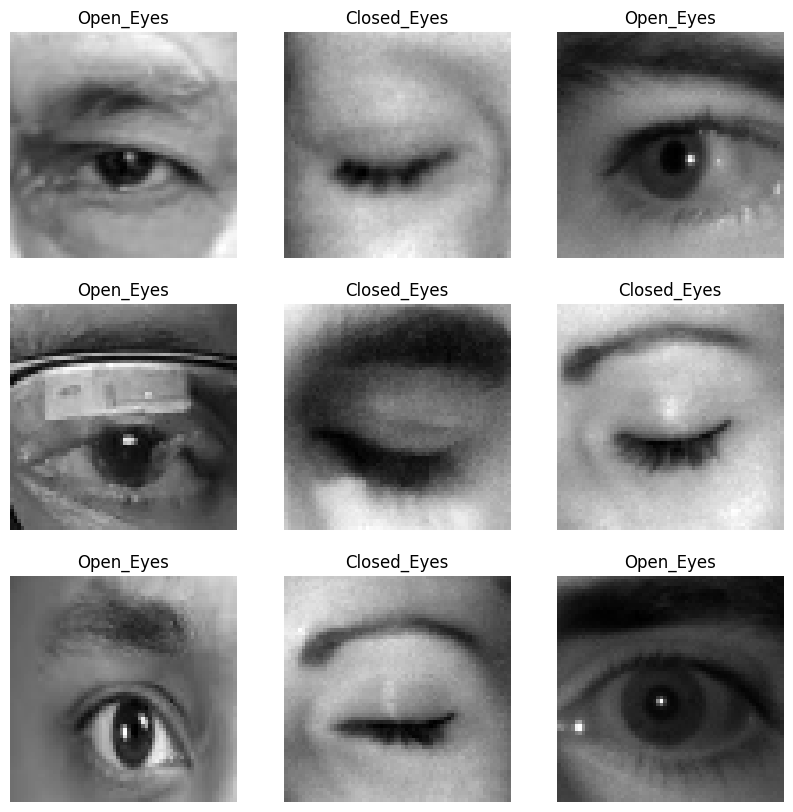

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in eye_train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(eye_classes[int(labels[i].numpy()[0])])
        plt.axis("off")

plt.show()

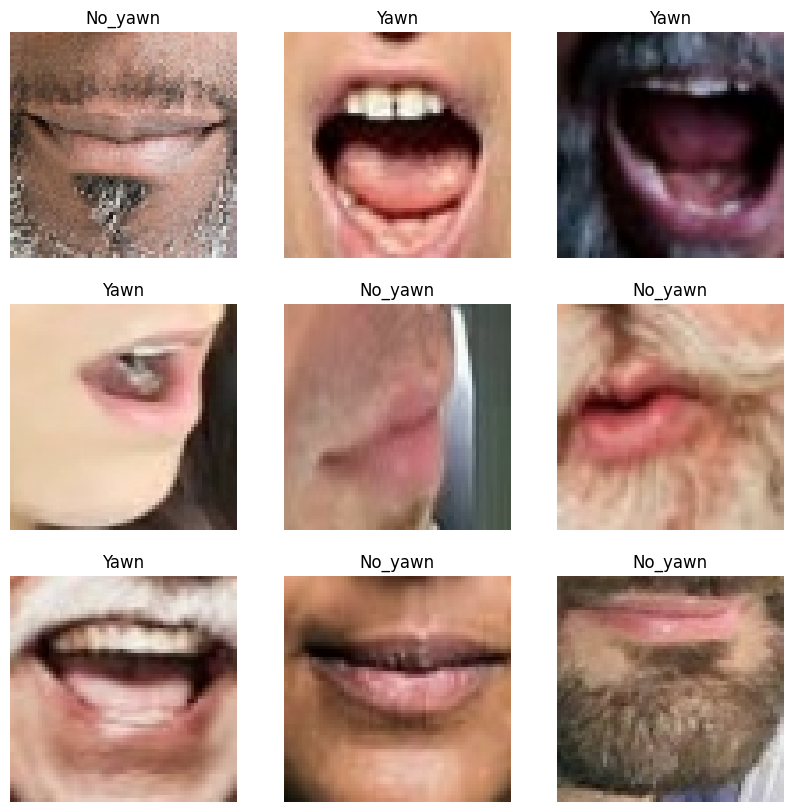

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in mouth_train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(mouth_classes[int(labels[i].numpy()[0])])
        plt.axis("off")

plt.show()

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

eye_train_ds = eye_train_ds.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

eye_val_ds = eye_val_ds.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

eye_test_ds = eye_test_ds.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

In [ ]:
mouth_train_ds = mouth_train_ds.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

mouth_val_ds = mouth_val_ds.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

mouth_test_ds = mouth_test_ds.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

In [ ]:
for images, labels in eye_train_ds.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: -0.9882707
Maximum pixel value: 0.9685317


In [ ]:
for images, labels in mouth_train_ds.take(1):
    print("Mouth Minimum:", tf.reduce_min(images).numpy())
    print("Mouth Maximum:", tf.reduce_max(images).numpy())

Mouth Minimum: -1.0
Mouth Maximum: 1.0


In [ ]:
eye_data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [ ]:
mouth_data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
eye_base_model = MobileNetV2(
    weights="imagenet", include_top=False,input_shape=(64, 64, 3))

eye_base_model.trainable = False


eye_model = tf.keras.Sequential([ tf.keras.layers.Input(shape=(64, 64, 1)),

    tf.keras.layers.Lambda(
       lambda x: tf.image.grayscale_to_rgb(x)),

    eye_data_augmentation, eye_base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense( 128, activation="relu"),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense( 1, activation="sigmoid")])

/tmp/ipykernel_2544/1635073969.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  eye_base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
eye_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])

In [ ]:

mouth_base_model = MobileNetV2(
    weights="imagenet", include_top=False, input_shape=(64, 64, 3))

mouth_base_model.trainable = False


mouth_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64, 64, 3)),
    mouth_data_augmentation,mouth_base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense( 128, activation="relu"),

    tf.keras.layers.Dropout(0.5),
 tf.keras.layers.Dense( 1,activation="sigmoid" )])

/tmp/ipykernel_2544/2632153144.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mouth_base_model = MobileNetV2(


In [ ]:
for i, layer in enumerate(eye_model.layers):
    print(i, layer.name, type(layer).__name__)

0 lambda Lambda
1 sequential Sequential
2 mobilenetv2_1.00_224 Functional
3 global_average_pooling2d GlobalAveragePooling2D
4 dense Dense
5 dropout Dropout
6 dense_1 Dense


**Training**

In [ ]:
mouth_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

mouth_history = mouth_model.fit(
    mouth_train_ds,
    validation_data=mouth_val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 41s 177ms/step - accuracy: 0.8980 - loss: 0.2670 - val_accuracy: 0.9580 - val_loss: 0.1281
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 22s 160ms/step - accuracy: 0.9379 - loss: 0.1787 - val_accuracy: 0.9637 - val_loss: 0.1336
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 23s 168ms/step - accuracy: 0.9404 - loss: 0.1660 - val_accuracy: 0.9410 - val_loss: 0.1465
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 22s 164ms/step - accuracy: 0.9460 - loss: 0.1549 - val_accuracy: 0.9512 - val_loss: 0.1323


In [ ]:
mouth_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,277 (10.49 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,196 (1.25 MB)

In [ ]:
eye_history = eye_model.fit(
    eye_train_ds,
    validation_data=eye_val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 30s 175ms/step - accuracy: 0.9700 - loss: 0.0816 - val_accuracy: 0.9866 - val_loss: 0.0490
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.9896 - loss: 0.0360 - val_accuracy: 0.9821 - val_loss: 0.0425
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 22s 164ms/step - accuracy: 0.9941 - loss: 0.0234 - val_accuracy: 0.9568 - val_loss: 0.0986
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 21s 156ms/step - accuracy: 0.9922 - loss: 0.0260 - val_accuracy: 0.9851 - val_loss: 0.0397
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 21s 159ms/step - accuracy: 0.9927 - loss: 0.0212 - val_accuracy: 0.9702 - val_loss: 0.0918
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 40s 152ms/step - accuracy: 0.9939 - loss: 0.0209 - val_accuracy: 0.9807 - val_loss: 0.0523
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 22s 164ms/step - accuracy: 0.9939 - loss: 0.0230 - val_accuracy: 0.9673 - val_loss: 0.0774


In [ ]:
eye_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,277 (10.49 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,196 (1.25 MB)

In [ ]:
mouth_base_model.trainable = True

for layer in mouth_base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
eye_base_model.trainable = True

for layer in eye_base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
from tensorflow.keras.optimizers import Adam

mouth_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
print("Number of layers in the base model:", len(mouth_base_model.layers))

Number of layers in the base model: 154


In [ ]:
eye_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
print("Number of layers in the base model:", len(eye_base_model.layers))

Number of layers in the base model: 154


In [ ]:
mouth_fine_tune_history = mouth_model.fit(
    mouth_train_ds,
    validation_data=mouth_val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 48s 266ms/step - accuracy: 0.8559 - loss: 0.3836 - val_accuracy: 0.9512 - val_loss: 0.1330
Epoch 2/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 33s 247ms/step - accuracy: 0.8920 - loss: 0.2925 - val_accuracy: 0.9501 - val_loss: 0.1442
Epoch 3/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 35s 256ms/step - accuracy: 0.9110 - loss: 0.2434 - val_accuracy: 0.9558 - val_loss: 0.1390


In [ ]:
eye_fine_tune_history = eye_model.fit(
    eye_train_ds,
    validation_data=eye_val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 47s 265ms/step - accuracy: 0.8663 - loss: 0.5393 - val_accuracy: 0.9702 - val_loss: 0.0849
Epoch 2/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 39s 252ms/step - accuracy: 0.9466 - loss: 0.1821 - val_accuracy: 0.9732 - val_loss: 0.0645
Epoch 3/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 34s 255ms/step - accuracy: 0.9655 - loss: 0.1117 - val_accuracy: 0.9673 - val_loss: 0.0716


In [ ]:
y_true = []
y_pred = []

for images, labels in mouth_test_ds:
    predictions = mouth_model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend((predictions >= 0.5).astype(int).flatten())

print(classification_report(
    y_true,
    y_pred,
    target_names=["No_yawn", "Yawn"]
))

              precision    recall  f1-score   support

     No_yawn       0.98      0.96      0.97       469
        Yawn       0.96      0.98      0.97       448

    accuracy                           0.97       917
   macro avg       0.97      0.97      0.97       917
weighted avg       0.97      0.97      0.97       917



In [ ]:
y_true = []
y_pred = []

for images, labels in eye_test_ds:
    predictions = eye_model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend((predictions >= 0.5).astype(int).flatten())

print(classification_report(
    y_true,
    y_pred,
    target_names=["Closed_Eyes", "Open_Eyes"]
))

              precision    recall  f1-score   support

 Closed_Eyes       0.99      0.98      0.99       361
   Open_Eyes       0.97      0.98      0.97       186

    accuracy                           0.98       547
   macro avg       0.98      0.98      0.98       547
weighted avg       0.98      0.98      0.98       547



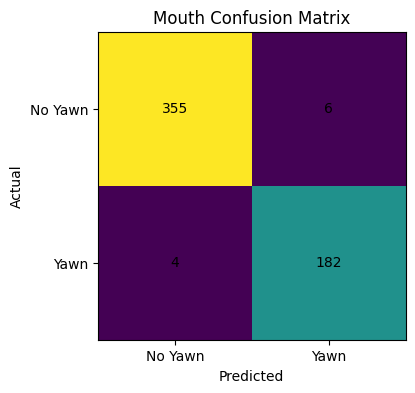

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Mouth Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No Yawn", "Yawn"])
plt.yticks([0, 1], ["No Yawn", "Yawn"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [ ]:
test_loss, test_accuracy = mouth_model.evaluate(mouth_test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.9662 - loss: 0.1303
Test Loss: 0.13025285303592682
Test Accuracy: 0.9661940932273865
Test Accuracy (%): 96.61940932273865


In [ ]:
test_loss, test_accuracy = eye_model.evaluate(eye_test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9817 - loss: 0.0520
Test Loss: 0.05202248692512512
Test Accuracy: 0.9817184805870056
Test Accuracy (%): 98.17184805870056


In [ ]:
eye_model.save("/content/eye_model.keras")
mouth_model.save("/content/mouth_model.keras")

print("Models saved successfully.")

Models saved successfully.


# Face & Feature Detection

In [ ]:
import os

print("Eye model:", os.path.exists("/content/eye_model.keras"))
print("Mouth model:", os.path.exists("/content/mouth_model.keras"))

Eye model: True
Mouth model: True


In [ ]:
!wget -q -O /content/face_detection_yunet_2023mar.onnx \
https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx

import os
print("YuNet downloaded:",os.path.exists("/content/face_detection_yunet_2023mar.onnx"))

YuNet downloaded: True


In [ ]:
import cv2
import numpy as np

print("Initializing Face Detector...")

face_detector = cv2.FaceDetectorYN.create(
    "/content/face_detection_yunet_2023mar.onnx",
    "",
    (320, 320),
    0.6,
    0.3,
    5000)

print("Face detector ready")

Initializing Face Detector...
Face detector ready


In [ ]:
def detect_face(frame):

    height, width = frame.shape[:2]
    face_detector.setInputSize((width, height))

    _, faces = face_detector.detect(frame)

    if faces is None or len(faces) == 0:
        return None

    largest_face = max(
        faces,
        key=lambda face: face[2] * face[3])

    return largest_face

In [ ]:
def extract_eye_mouth_regions(frame, face):

    x, y, w, h = face[:4].astype(int)

    # YuNet landmark positions
    right_eye = face[4:6]
    left_eye = face[6:8]
    nose = face[8:10]
    right_mouth = face[10:12]
    left_mouth = face[12:14]

    # Eye region
    eye_x1 = int(min(right_eye[0], left_eye[0]) - 0.35 * w)
    eye_x2 = int(max(right_eye[0], left_eye[0]) + 0.35 * w)

    eye_y1 = int(min(right_eye[1], left_eye[1]) - 0.15 * h)
    eye_y2 = int(max(right_eye[1], left_eye[1]) + 0.25 * h)

    # Mouth region
    mouth_x1 = int(min(right_mouth[0], left_mouth[0]) - 0.20 * w)
    mouth_x2 = int(max(right_mouth[0], left_mouth[0]) + 0.20 * w)

    mouth_y1 = int(min(right_mouth[1], left_mouth[1]) - 0.20 * h)
    mouth_y2 = int(max(right_mouth[1], left_mouth[1]) + 0.35 * h)

    # Keep coordinates inside the frame
    eye_x1 = max(0, eye_x1)
    eye_y1 = max(0, eye_y1)
    eye_x2 = min(frame.shape[1], eye_x2)
    eye_y2 = min(frame.shape[0], eye_y2)

    mouth_x1 = max(0, mouth_x1)
    mouth_y1 = max(0, mouth_y1)
    mouth_x2 = min(frame.shape[1], mouth_x2)
    mouth_y2 = min(frame.shape[0], mouth_y2)

    eye_crop = frame[eye_y1:eye_y2, eye_x1:eye_x2]
    mouth_crop = frame[mouth_y1:mouth_y2, mouth_x1:mouth_x2]

    return (
        eye_crop,
        mouth_crop,
        (eye_x1, eye_y1, eye_x2, eye_y2),
        (mouth_x1, mouth_y1, mouth_x2, mouth_y2))

In [ ]:
print("Face & feature detection functions are ready")

Face & feature detection functions are ready


In [ ]:
import tensorflow as tf

print("Loading models...")

eye_model = tf.keras.models.load_model(
    "/content/eye_model.keras",
    safe_mode=False
)

print("Eye model loaded")

mouth_model = tf.keras.models.load_model(
    "/content/mouth_model.keras",
    safe_mode=False
)

print("Mouth model loaded")

Loading models...
Eye model loaded
Mouth model loaded


In [ ]:
import tensorflow as tf

for layer in eye_model.layers:
    if isinstance(layer, tf.keras.layers.Lambda):
        layer.function.__globals__["tf"] = tf
        print("Eye Lambda fixed")

Eye Lambda fixed


In [ ]:
import tensorflow as tf
import numpy as np

for layer in mouth_model.layers:
    if isinstance(layer, tf.keras.layers.Lambda):
        layer.function.__globals__["tf"] = tf
        print("Mouth Lambda fixed")

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def predict_eye(eye_crop):

    eye_crop = cv2.resize(eye_crop, (64, 64))

    if len(eye_crop.shape) == 3:
        eye_crop = cv2.cvtColor(
            eye_crop,
            cv2.COLOR_BGR2GRAY
        )

    eye_crop = np.expand_dims(eye_crop, axis=-1)

    eye_crop = eye_crop.astype(np.float32)

    eye_crop = preprocess_input(eye_crop)


    eye_crop = np.expand_dims(eye_crop, axis=0)

    prediction = eye_model.predict(
        eye_crop,
        verbose=0
    )[0][0]

    if prediction < 0.5:
        state = "Closed"
    else:
        state = "Open"

    return state, float(prediction)

In [ ]:
def predict_mouth(mouth_crop):

    mouth_crop = cv2.resize(mouth_crop, (64, 64))

    if len(mouth_crop.shape) == 2:
        mouth_crop = cv2.cvtColor(
            mouth_crop,
            cv2.COLOR_GRAY2RGB
        )

    mouth_crop = mouth_crop.astype(np.float32)

    mouth_crop = preprocess_input(mouth_crop)

    mouth_crop = np.expand_dims(mouth_crop, axis=0)

    prediction = mouth_model.predict(
        mouth_crop,
        verbose=0
    )[0][0]

    if prediction < 0.5:
        state = "No Yawn"
    else:
        state = "Yawn"

    return state, float(prediction)

In [ ]:
from google.colab import files
import cv2
import numpy as np

uploaded = files.upload()

image_path = next(iter(uploaded))

image = cv2.imread(image_path)

print(image.shape)

Saving Jam on the Brakes Meaning & Definition.jfif to Jam on the Brakes Meaning & Definition.jfif
(736, 736, 3)


In [ ]:
face = detect_face(image)

if face is None:

    print("No face detected.")

else:

    result = extract_eye_mouth_regions(
        image,
        face
    )

    eye_crop = result[0]
    mouth_crop = result[1]

    eye_state, eye_score = predict_eye(
        eye_crop
    )

    mouth_state, mouth_score = predict_mouth(
        mouth_crop
    )

    print("Eye:", eye_state)
    print("Mouth:", mouth_state)

Eye: Open
Mouth: Yawn


In [ ]:
if eye_state == "Closed" and mouth_state == "Yawn":
    final_result = "DROWSY"

elif eye_state == "Closed":
    final_result = "POSSIBLE DROWSINESS"

elif mouth_state == "Yawn":
    final_result = "POSSIBLE DROWSINESS"

else:
    final_result = "ALERT"

print("Eye Status:", eye_state)
print("Mouth Status:", mouth_state)
print("Final Result:", final_result)

Eye Status: Open
Mouth Status: Yawn
Final Result: POSSIBLE DROWSINESS


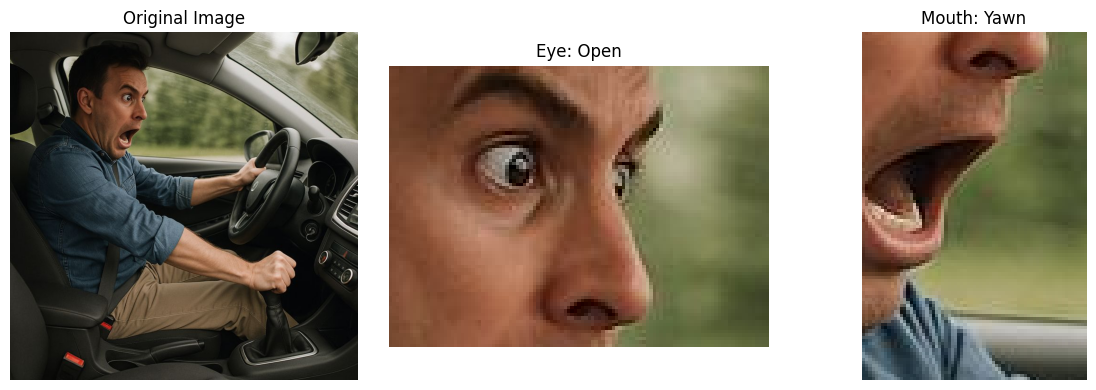

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(eye_crop, cv2.COLOR_BGR2RGB))
plt.title(f"Eye: {eye_state}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(mouth_crop, cv2.COLOR_BGR2RGB))
plt.title(f"Mouth: {mouth_state}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os

for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith('.onnx'):
            print(os.path.join(root, file))

/content/face_detection_yunet_2023mar.onnx


In [ ]:
import os

BLYNK_TOKEN = os.getenv("BLYNK_TOKEN")

In [ ]:
from google.colab import files

files.download("/content/face_detection_yunet_2023mar.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("/content/eye_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Get the existing layers from the trained model
eye_augmentation = eye_model.layers[1]
eye_base_model = eye_model.layers[2]
eye_gap = eye_model.layers[3]
eye_dense = eye_model.layers[4]
eye_dropout = eye_model.layers[5]
eye_output = eye_model.layers[6]

# New input: RGB instead of grayscale
inputs = tf.keras.Input(shape=(64, 64, 3))

x = eye_augmentation(inputs)
x = eye_base_model(x)
x = eye_gap(x)
x = eye_dense(x)
x = eye_dropout(x)
outputs = eye_output(x)

# Create deployment model
eye_model_deploy = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

eye_model_deploy.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 1,690,497 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [ ]:
eye_model_deploy.save("eye_model_deploy.keras")

In [ ]:
import os

print(os.path.exists("eye_model_deploy.keras"))

True


In [ ]:
import os

print("Eye model:", os.path.exists("/content/eye_model.keras"))
print("Mouth model:", os.path.exists("/content/mouth_model.keras"))
print("Eye deploy model:", os.path.exists("/content/eye_model_deploy.keras"))
print("YuNet:", os.path.exists("/content/face_detection_yunet_2023mar.onnx"))

Eye model: True
Mouth model: True
Eye deploy model: True
YuNet: True


In [ ]:
import os

for file in os.listdir("/content"):
    if file.endswith((".keras", ".onnx")):
        print(file)

face_detection_yunet_2023mar.onnx
eye_model.keras
mouth_model.keras
eye_model_deploy.keras


In [ ]:
import sys
import tensorflow as tf
import numpy as np
import matplotlib
import sklearn
import cv2

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)
print("OpenCV:", cv2.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow: 2.20.0
NumPy: 2.0.2
Matplotlib: 3.10.0
Scikit-learn: 1.6.1
OpenCV: 5.0.0


In [ ]:
!pip show opencv-python
!pip show opencv-python-headless

Name: opencv-python
Version: 5.0.0.93
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy
Required-by: dopamine_rl
Name: opencv-python-headless
Version: 5.0.0.93
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy
Required-by: albucore, albumentations


In [ ]:
!pip install streamlit -q

In [ ]:
!pip show streamlit


Name: streamlit
Version: 1.61.1
Summary: A faster way to build and share data apps
Home-page: https://streamlit.io
Author: 
Author-email: Snowflake Inc <hello@streamlit.io>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: altair, anyio, blinker, click, httptools, itsdangerous, numpy, packaging, pandas, pillow, protobuf, pyarrow, pydeck, python-multipart, requests, starlette, tenacity, toml, typing-extensions, uvicorn, watchdog, websockets
Required-by: 
